In [1]:
import numpy as np
import mne
import os
import pywt
import scipy.io as sio
from scipy import signal
from scipy.signal import hilbert
from matplotlib.ticker import ScalarFormatter
from statsmodels.tsa.stattools import acf
from scipy.ndimage import gaussian_filter1d


from NeuralFieldManifold.models import AR, TAR
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.pub_utils import *

# capture future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

set_pub_style()

import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import plotly.graph_objects as go
from NeuralFieldManifold.fits.two_torus import two_torus_fit, plot_two_torus_fit

/home/potato/miniconda3/envs/manifold/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
xs, time, Fs = np.load("data/monkey_15_min.npz").values()
xs_rescaled = (xs - np.min(xs)) / (np.max(xs) - np.min(xs)) * 2 - 1

In [3]:
def sweep_fits(windows, lam=0.1, n_jobs=-1):
    fits = Parallel(n_jobs=n_jobs)(
        delayed(two_torus_fit)(w['points'], lam=lam)
        for w in windows
    )
    return [{**w, **f} for w, f in zip(windows, fits)]

def make_windows(xs, Fs, embedding_dim, tau, starts_sec, window_sec=2):
    window_samples = int(window_sec * Fs)
    windows = []
    for t in starts_sec:
        start = int(t * Fs)
        segment = xs[start:start + window_samples]
        pts = np.asarray(embed(segment, embedding_dim, tau))
        windows.append({
            'points': pts,
            'start_sec': t,
            'end_sec': t + window_sec,
        })
    return windows

In [4]:
def generate_bad_ar_data(n_samples=600, ar_order=2, seed=None):
    """AR process with only real poles (no oscillatory modes), driven by white noise."""
    rng = np.random.default_rng(seed)

    if ar_order == 2:
        # two real stable poles — no oscillation
        p1, p2 = 0.6, -0.4
        a1 = p1 + p2        # 0.2
        a2 = -(p1 * p2)     # 0.24
        coeffs = np.array([a1, a2])
    elif ar_order == 4:
        # four real stable poles — no oscillation
        poles = np.array([0.55, -0.45, 0.35, -0.25])
        poly = np.polynomial.polynomial.polyfromroots(poles)
        # polyfromroots gives [c0, c1, ..., cn] for c0 + c1*z + ...
        # AR coeffs are -poly[:-1][::-1] / poly[-1] but poly[-1]=1 for monic
        # Actually for z^4 - a1*z^3 - ... = (z-p1)(z-p2)(z-p3)(z-p4)
        # easier: use np.poly which gives [1, -a1, -a2, ...] descending
        char_poly = np.poly(poles)  # [1, -(sum poles), ..., prod poles]
        coeffs = -char_poly[1:]     # AR coefficients
    else:
        raise ValueError("ar_order must be 2 or 4")

    x = np.zeros(n_samples, dtype=np.float32)
    x[:ar_order] = rng.standard_normal(ar_order).astype(np.float32)
    for i in range(ar_order, n_samples):
        ar_pred = sum(coeffs[j] * x[i - j - 1] for j in range(ar_order))
        x[i] = ar_pred + rng.standard_normal()
    return x


def envelope_normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x)) * 2 - 1

In [5]:
window_size = 5
optimal_tau = 30
max_start = (len(xs_rescaled) / Fs) - window_size
sampled_starts = np.sort(np.random.uniform(0, max_start, 1000))

time_sweep_windows = make_windows(
    xs_rescaled,
    Fs=Fs,
    embedding_dim=3,
    tau=optimal_tau,
    starts_sec=sampled_starts.tolist(),
    window_sec=window_size,
)
torus_sweep = sweep_fits(time_sweep_windows)


In [6]:
null_xs = generate_bad_ar_data(n_samples=len(xs), seed=42)
null_xs_rescaled = envelope_normalize(null_xs)

null_windows = make_windows(
    null_xs_rescaled,
    Fs=Fs,
    embedding_dim=3,
    tau=optimal_tau,
    starts_sec=sampled_starts.tolist(),
    window_sec=window_size,
)
null_sweep = sweep_fits(null_windows)

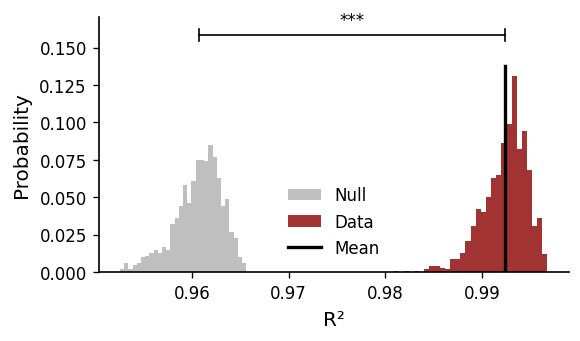

In [17]:
from scipy.stats import mannwhitneyu

def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

r_squared_vals = np.array([f['r_squared'] for f in torus_sweep])
r_squared_weights = np.ones_like(r_squared_vals) / len(r_squared_vals)

null_r2 = np.array([f['r_squared'] for f in null_sweep])
null_r2_weights = np.ones_like(null_r2) / len(null_r2)
_, p_r2 = mannwhitneyu(r_squared_vals, null_r2, alternative='two-sided')

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(null_r2, bins=30, weights=null_r2_weights, color='gray', alpha=0.5, label='Null')
ax.hist(r_squared_vals, bins=30, weights=r_squared_weights, color=color_alt, alpha=0.8, label='Data')
y_top = ax.get_ylim()[1]
ax.plot([r_squared_vals.mean(), r_squared_vals.mean()], [0, y_top], color='black', linewidth=2, label='Mean')

bar_y = y_top * 1.15
tick_h = y_top * 0.03
ax.plot([null_r2.mean(), null_r2.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([r_squared_vals.mean(), r_squared_vals.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([null_r2.mean(), r_squared_vals.mean()], [bar_y, bar_y], color='black', linewidth=1, clip_on=False)
ax.text((null_r2.mean() + r_squared_vals.mean()) / 2, bar_y + tick_h, p_to_stars(p_r2), ha='center', va='bottom', fontsize=10, clip_on=False)

prettify(ax, xlabel="R²", ylabel="Probability", add_legend=True)
plt.tight_layout()
plt.show()

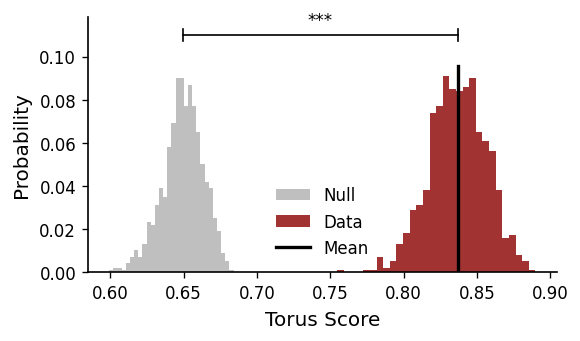

In [18]:
torus_score_vals = np.array([f['frac_inside'] for f in torus_sweep])
torus_score_weights = np.ones_like(torus_score_vals) / len(torus_score_vals)

null_ts = np.array([f['frac_inside'] for f in null_sweep])
null_ts_weights = np.ones_like(null_ts) / len(null_ts)
_, p_ts = mannwhitneyu(torus_score_vals, null_ts, alternative='two-sided')

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(null_ts, bins=30, weights=null_ts_weights, color='gray', alpha=0.5, label='Null')
ax.hist(torus_score_vals, bins=30, weights=torus_score_weights, color=color_alt, alpha=0.8, label='Data')
y_top = ax.get_ylim()[1]
ax.plot([torus_score_vals.mean(), torus_score_vals.mean()], [0, y_top], color='black', linewidth=2, label='Mean')

bar_y = y_top * 1.15
tick_h = y_top * 0.03
ax.plot([null_ts.mean(), null_ts.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([torus_score_vals.mean(), torus_score_vals.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([null_ts.mean(), torus_score_vals.mean()], [bar_y, bar_y], color='black', linewidth=1, clip_on=False)
ax.text((null_ts.mean() + torus_score_vals.mean()) / 2, bar_y + tick_h, p_to_stars(p_ts), ha='center', va='bottom', fontsize=10, clip_on=False)

prettify(ax, xlabel="Torus Score", ylabel="Probability", add_legend=True)
plt.tight_layout()
plt.show()

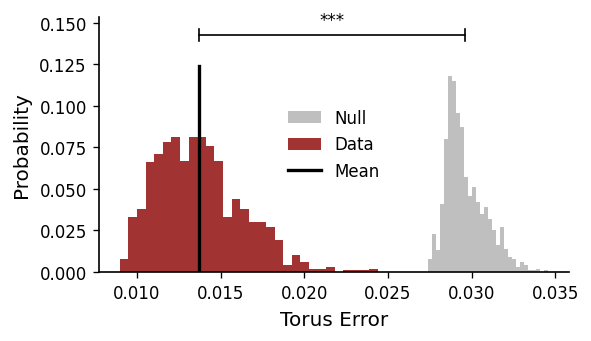

In [19]:
mean_error_vals = np.array([f['mean_error'] for f in torus_sweep])
mean_error_weights = np.ones_like(mean_error_vals) / len(mean_error_vals)

null_me = np.array([f['mean_error'] for f in null_sweep])
null_me_weights = np.ones_like(null_me) / len(null_me)
_, p_me = mannwhitneyu(mean_error_vals, null_me, alternative='two-sided')

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(null_me, bins=30, weights=null_me_weights, color='gray', alpha=0.5, label='Null')
ax.hist(mean_error_vals, bins=30, weights=mean_error_weights, color=color_alt, alpha=0.8, label='Data')
y_top = ax.get_ylim()[1]
ax.plot([mean_error_vals.mean(), mean_error_vals.mean()], [0, y_top], color='black', linewidth=2, label='Mean')

bar_y = y_top * 1.15
tick_h = y_top * 0.03
ax.plot([null_me.mean(), null_me.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([mean_error_vals.mean(), mean_error_vals.mean()], [bar_y - tick_h, bar_y + tick_h], color='black', linewidth=1, clip_on=False)
ax.plot([null_me.mean(), mean_error_vals.mean()], [bar_y, bar_y], color='black', linewidth=1, clip_on=False)
ax.text((null_me.mean() + mean_error_vals.mean()) / 2, bar_y + tick_h, p_to_stars(p_me), ha='center', va='bottom', fontsize=10, clip_on=False)

prettify(ax, xlabel="Torus Error", ylabel="Probability", add_legend=True)
plt.tight_layout()
plt.show()

# Cross animals

In [4]:
monkey_xs, monkey_Fs, monkey_tau = np.load("data/monkey_lfp.npz").values()
monkey_xs_rescaled = (monkey_xs - np.min(monkey_xs)) / (np.max(monkey_xs) - np.min(monkey_xs)) * 2 - 1
print("Monkey:", monkey_xs.shape, f"Fs={monkey_Fs}, tau={monkey_tau}")

mice_xs, mice_Fs, mice_tau = np.load("data/mice_lfp.npz").values()
mice_xs_rescaled = (mice_xs - np.min(mice_xs)) / (np.max(mice_xs) - np.min(mice_xs)) * 2 - 1
print("Mice:  ", mice_xs.shape, f"Fs={mice_Fs}, tau={mice_tau}")

eeg_data = np.load("data/eeg_processed.npz")
eeg_xs, eeg_Fs, eeg_tau = eeg_data['xs'], float(eeg_data['Fs']), int(eeg_data['tau'])
eeg_xs_rescaled = (eeg_xs - np.min(eeg_xs)) / (np.max(eeg_xs) - np.min(eeg_xs)) * 2 - 1
print("MiceEEG:", eeg_xs.shape, f"Fs={eeg_Fs}, tau={eeg_tau}")

Monkey: (10000,) Fs=500, tau=30
Mice:   (2500,) Fs=500.0, tau=10
MiceEEG: (1440000,) Fs=399.9997222222222, tau=7


In [ ]:
n_samples = 1000

# Monkey windows
monkey_tau_int = int(monkey_tau)
monkey_window_sec = 2
monkey_max_start = (len(monkey_xs_rescaled) / monkey_Fs) - monkey_window_sec
monkey_starts = np.sort(np.random.uniform(0, monkey_max_start, n_samples))

monkey_windows = make_windows(
    monkey_xs_rescaled, Fs=monkey_Fs, embedding_dim=3,
    tau=monkey_tau_int, starts_sec=monkey_starts.tolist(),
    window_sec=monkey_window_sec,
)
monkey_fits = sweep_fits(monkey_windows)

# Mice LFP windows
mice_tau_int = int(mice_tau)
mice_window_sec = 1
mice_max_start = (len(mice_xs_rescaled) / mice_Fs) - mice_window_sec
mice_starts = np.sort(np.random.uniform(0, mice_max_start, n_samples))

mice_windows = make_windows(
    mice_xs_rescaled, Fs=mice_Fs, embedding_dim=3,
    tau=mice_tau_int, starts_sec=mice_starts.tolist(),
    window_sec=mice_window_sec,
)
mice_fits = sweep_fits(mice_windows)

# Mice EEG windows
eeg_tau_int = int(eeg_tau)
eeg_window_sec = 2
eeg_max_start = (len(eeg_xs_rescaled) / eeg_Fs) - eeg_window_sec
eeg_starts = np.sort(np.random.uniform(0, eeg_max_start, n_samples))

eeg_windows = make_windows(
    eeg_xs_rescaled, Fs=eeg_Fs, embedding_dim=3,
    tau=eeg_tau_int, starts_sec=eeg_starts.tolist(),
    window_sec=eeg_window_sec,
)
eeg_fits = sweep_fits(eeg_windows)

print(f"Monkey fits: {len(monkey_fits)}, Mice LFP fits: {len(mice_fits)}, Mice EEG fits: {len(eeg_fits)}")

/tmp/ipykernel_3443696/2773694681.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


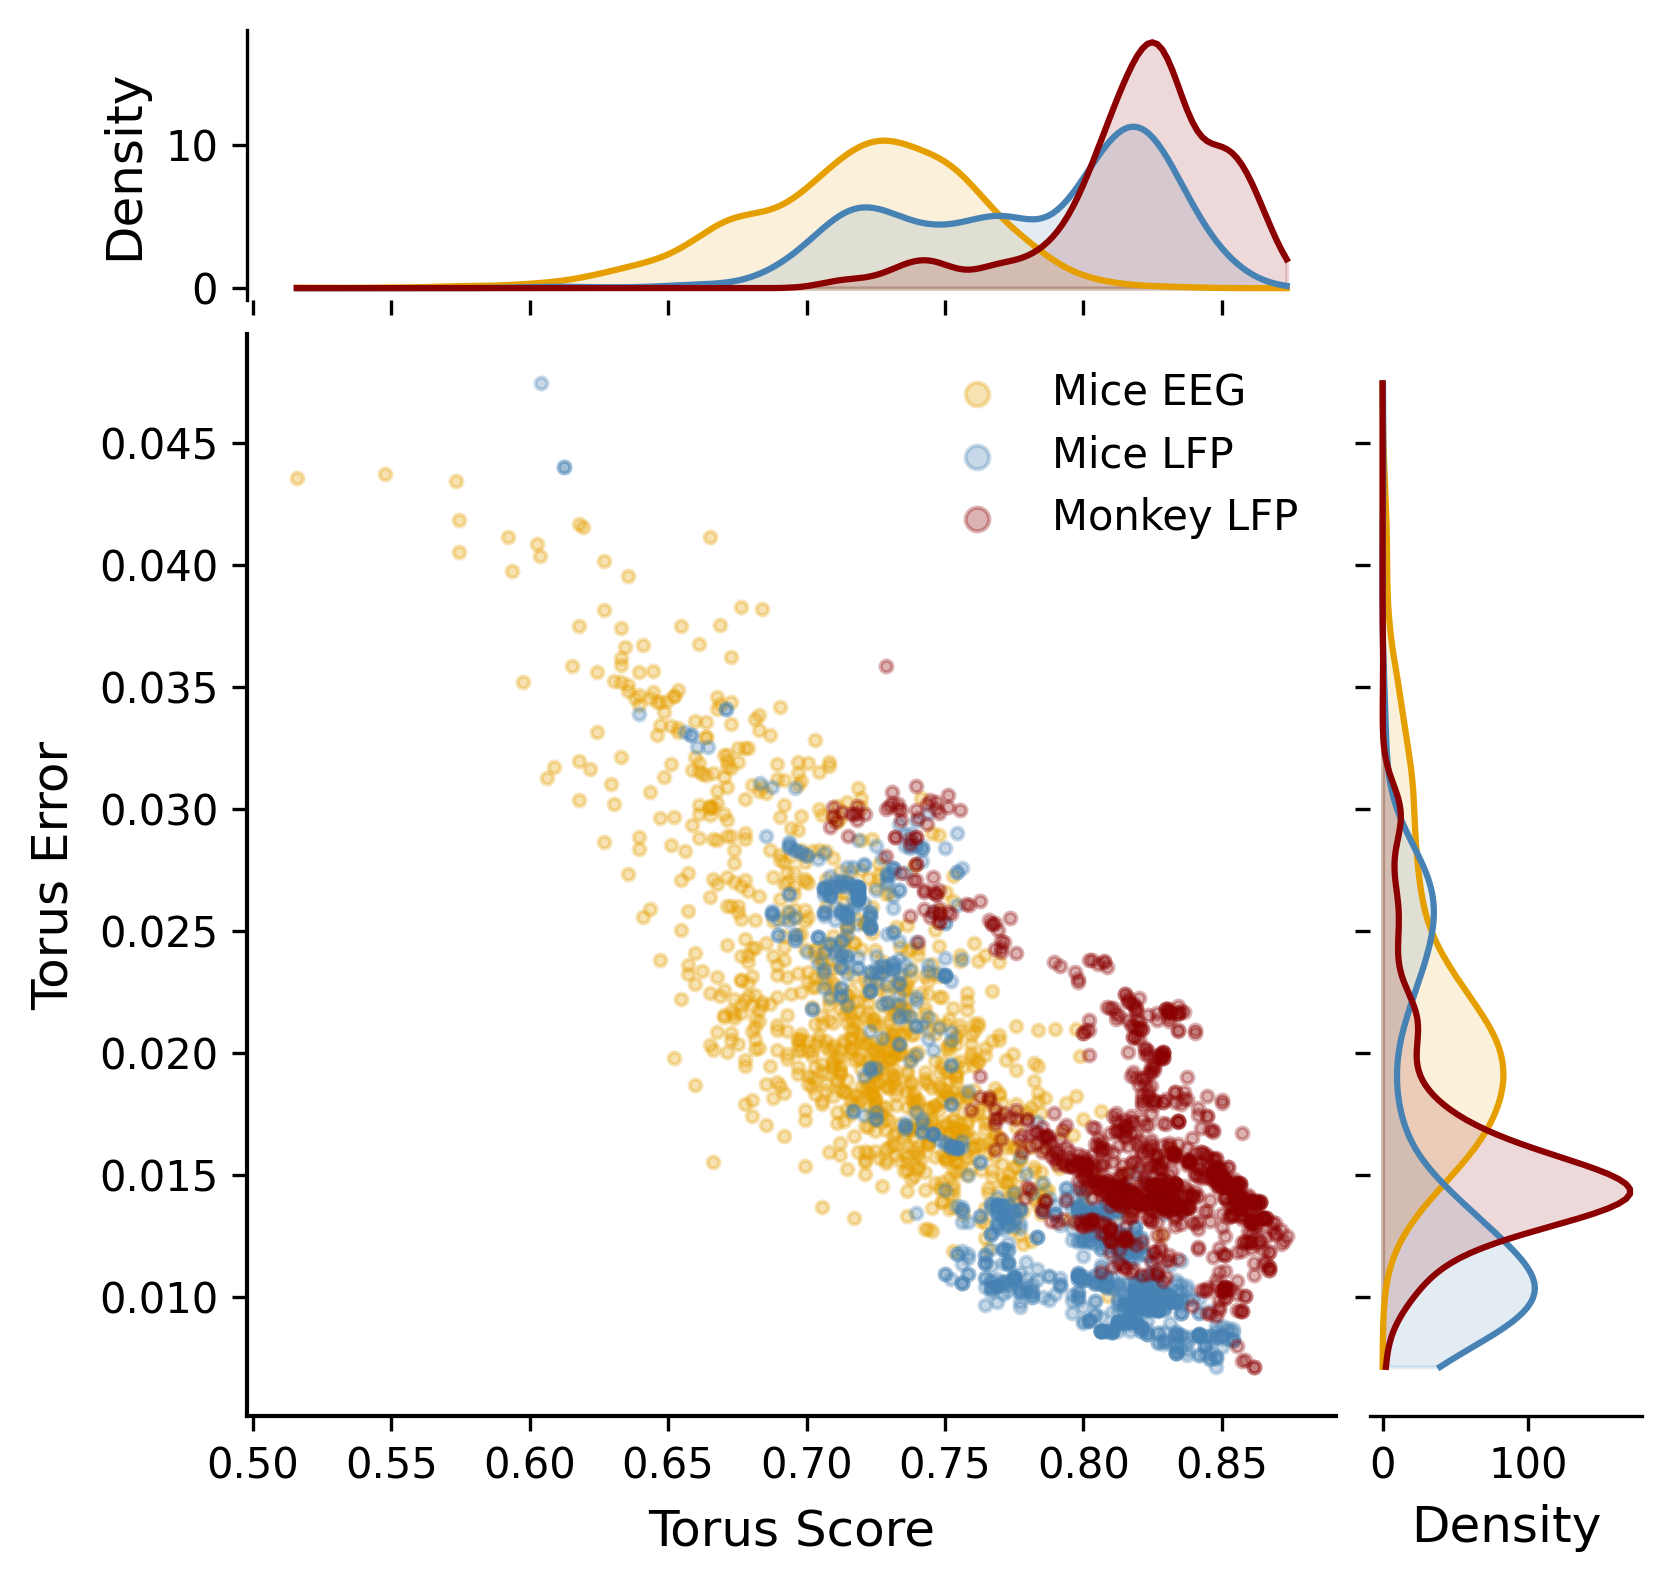

In [13]:
from scipy.stats import gaussian_kde

monkey_score = np.array([f['frac_inside'] for f in monkey_fits])
monkey_error = np.array([f['mean_error'] for f in monkey_fits])
mice_score = np.array([f['frac_inside'] for f in mice_fits])
mice_error = np.array([f['mean_error'] for f in mice_fits])
eeg_score = np.array([f['frac_inside'] for f in eeg_fits])
eeg_error = np.array([f['mean_error'] for f in eeg_fits])

_colors = {'monkey': color_alt, 'mice': 'steelblue', 'eeg': '#e69f00'}
_labels = {'monkey': 'Monkey LFP', 'mice': 'Mice LFP', 'eeg': 'Mice EEG'}

# Draw order: EEG first (behind), then mice, then monkey on top
_draw_order = ['eeg', 'mice', 'monkey']
_scores = {'monkey': monkey_score, 'mice': mice_score, 'eeg': eeg_score}
_errors = {'monkey': monkey_error, 'mice': mice_error, 'eeg': eeg_error}

fig = plt.figure(figsize=(6, 6), dpi=300)
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      hspace=0.05, wspace=0.05)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# Main scatter — EEG drawn first so it sits behind
for key in _draw_order:
    ax_main.scatter(_scores[key], _errors[key], s=8, alpha=0.3,
                    color=_colors[key], label=_labels[key], rasterized=True)

# Top marginal — torus score KDE
all_scores = np.concatenate([monkey_score, mice_score, eeg_score])
score_grid = np.linspace(all_scores.min(), all_scores.max(), 200)
for key in _draw_order:
    kde = gaussian_kde(_scores[key])
    y = kde(score_grid)
    ax_top.plot(score_grid, y, color=_colors[key], lw=1.5)
    ax_top.fill_between(score_grid, y, alpha=0.15, color=_colors[key])

# Right marginal — torus error KDE
all_errors = np.concatenate([monkey_error, mice_error, eeg_error])
error_grid = np.linspace(all_errors.min(), all_errors.max(), 200)
for key in _draw_order:
    kde = gaussian_kde(_errors[key])
    y = kde(error_grid)
    ax_right.plot(y, error_grid, color=_colors[key], lw=1.5)
    ax_right.fill_betweenx(error_grid, y, alpha=0.15, color=_colors[key])

# Styling
ax_top.tick_params(labelbottom=False)
ax_right.tick_params(labelleft=False)
ax_top.grid(False)
ax_right.grid(False)
for spine in ['top', 'right']:
    ax_top.spines[spine].set_visible(False)
    ax_right.spines[spine].set_visible(False)
ax_top.spines['bottom'].set_visible(False)
ax_right.spines['left'].set_visible(False)

prettify(ax_main, xlabel="Torus Score", ylabel="Torus Error")
ax_main.legend(frameon=False, markerscale=2, loc='upper right')
ax_top.set_ylabel("Density")
ax_right.set_xlabel("Density")

plt.tight_layout()
plt.show()